# Optimization Lab: Gradient Descent for Linear and Logistic Regression

In supervised learning, training a model means minimizing an **empirical risk** of the form
$$
  \min_{\theta \in \mathbb{R}^d} \; \mathcal{L}(\theta)
  \quad \text{with} \quad
  \mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n \ell(\theta; x_i, y_i) \enspace,
$$
where $(x_i, y_i)$ are the training samples and $\ell$ is a per-sample loss. Different models
correspond to different choices of $\ell$, but the **optimization machinery is the same**.

In this lab we will:

0. build intuition for gradient descent on a simple **toy function**,
1. write the loss and gradient of **linear regression**,
2. implement a single, generic **gradient descent** and test it on linear regression,
3. reuse the *exact same* optimizer on **logistic regression**,
4. speed it up with **stochastic** and **mini-batch** gradient descent.

Let us start with the imports we will need throughout.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)  # fixed seed for reproducibility

## Part 0: Building intuition on a toy problem

Before touching any model, let us see what gradient descent *actually does*. The idea is simple:
**at each step, move in the direction that decreases the function the most**, i.e. against the
gradient,
$$
  \theta_{t+1} = \theta_t - \gamma \, \nabla f(\theta_t) \enspace,
$$
where the **step size** $\gamma > 0$ controls how big each step is.

Take a simple 1D function $f(\theta) = (\theta - 3)^2$, whose minimum is obviously at
$\theta^\star = 3$. Its gradient is $f'(\theta) = 2(\theta - 3)$. Let us run a few iterations and
*watch the iterates roll downhill*. (Everything in this part is provided, just run the cells and
look at the pictures.)

In [2]:
def f(theta):
    return (theta - 3.0) ** 2

def grad_f(theta):
    return 2.0 * (theta - 3.0)

def run_1d(theta0, step_size, n_iter=15):
    """Run 1D gradient descent and return every iterate."""
    iterates = [theta0]
    for _ in range(n_iter):
        iterates.append(iterates[-1] - step_size * grad_f(iterates[-1]))
    return np.array(iterates)

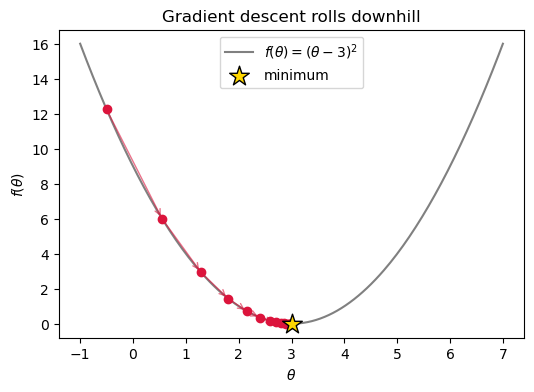

In [3]:
grid = np.linspace(-1, 7, 200)
iterates = run_1d(theta0=-0.5, step_size=0.15, n_iter=15)

plt.figure(figsize=(6, 4))
plt.plot(grid, f(grid), color='gray', label=r'$f(\theta)=(\theta-3)^2$')
plt.plot(iterates, f(iterates), 'o', color='crimson', markersize=6, zorder=4)
for a, b in zip(iterates[:-1], iterates[1:]):  # arrows between successive iterates
    plt.annotate('', xy=(b, f(b)), xytext=(a, f(a)),
                 arrowprops=dict(arrowstyle='->', color='crimson', alpha=0.6))
plt.scatter([3], [0], marker='*', s=220, color='gold', edgecolor='k', zorder=5,
            label='minimum')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$f(\theta)$')
plt.title('Gradient descent rolls downhill')
plt.legend()
plt.show()

The step size $\gamma$ is the single most important hyperparameter. **Too small** and the
iterates crawl; **too large** and they overshoot and may even diverge. The triptych below shows the
same descent for three step sizes.

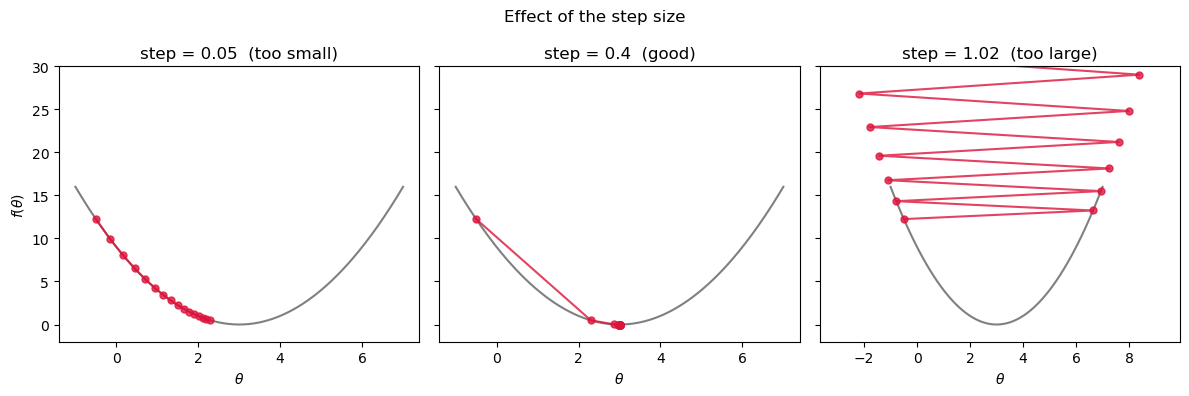

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (gamma, name) in zip(axs, [(0.05, 'too small'), (0.4, 'good'), (1.02, 'too large')]):
    iterates = run_1d(theta0=-0.5, step_size=gamma, n_iter=15)
    ax.plot(grid, f(grid), color='gray')
    ax.plot(iterates, f(iterates), 'o-', color='crimson', markersize=5, alpha=0.8)
    ax.set_title(f'step = {gamma}  ({name})')
    ax.set_xlabel(r'$\theta$')
    ax.set_ylim(-2, 30)
axs[0].set_ylabel(r'$f(\theta)$')
plt.suptitle('Effect of the step size')
plt.tight_layout()
plt.show()

In more than one dimension we can no longer draw the curve, but we can draw the **level sets**
(contour lines) of $f$ and the **path** taken by the iterates. Each step is perpendicular to the
level sets and points toward the minimum. Here is gradient descent on a 2D bowl
$f(\theta) = \tfrac12 \theta^\top A\, \theta$.

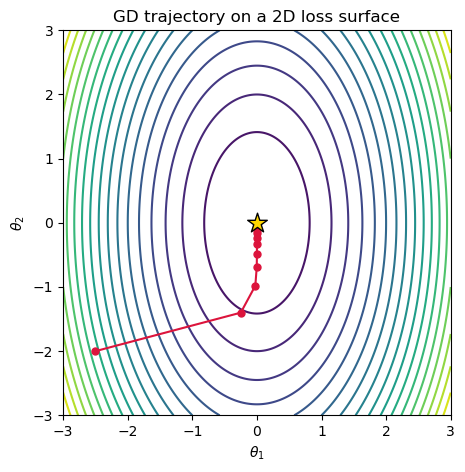

In [5]:
A = np.array([[3.0, 0.0],
              [0.0, 1.0]])  # different curvature along each axis gives an 'elbow' path

def grad_f2(theta):
    return A @ theta

theta = np.array([-2.5, -2.0])
trajectory = [theta.copy()]
for _ in range(20):
    theta = theta - 0.3 * grad_f2(theta)
    trajectory.append(theta.copy())
trajectory = np.array(trajectory)

g = np.linspace(-3, 3, 200)
G1, G2 = np.meshgrid(g, g)
Z = 0.5 * (A[0, 0] * G1 ** 2 + A[1, 1] * G2 ** 2)

plt.figure(figsize=(5, 5))
plt.contour(G1, G2, Z, levels=20, cmap='viridis')
plt.plot(trajectory[:, 0], trajectory[:, 1], 'o-', color='crimson', markersize=5)
plt.scatter([0], [0], marker='*', s=220, color='gold', edgecolor='k', zorder=5)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('GD trajectory on a 2D loss surface')
plt.show()

Keep this picture in mind: in the rest of the lab, $f$ is the **training loss**, $\theta$ is the
**model's parameters**, and gradient descent does exactly this, it walks downhill on the loss
surface. Let us now build a real loss.

## Part 1: Linear regression

We consider $n$ pairs $(x_i, y_i) \in \mathbb{R}^d \times \mathbb{R}$ and look for a linear
predictor $g_\theta(x) = \theta^\top x$. The prediction error is measured with the square loss
$\ell(\theta; x, y) = (\theta^\top x - y)^2$, so the problem becomes
$$
  \min_{\theta \in \mathbb{R}^d} \; \frac{1}{2n} \sum_{i=1}^n (\theta^\top x_i - y_i)^2 \enspace.
$$

Let us generate a dataset.

In [6]:
d = 10
n = 1_000

true_theta = np.ones(d)

X_reg = rng.standard_normal((n, d))
y_reg = X_reg @ true_theta + 0.2 * rng.standard_normal(n)

Here, we generated features $(x_1, \ldots, x_n)$ from a Gaussian distribution and paired each
$x_i$ with a value $y_i = x_i^\top \theta^\star + \varepsilon_i$, where $\theta^\star$ is the
*true* parameter and $\varepsilon_i$ is independent Gaussian noise.

### Question 1.1
Create a function `linreg_loss(theta, X, y)` that returns the average loss
$\frac{1}{2n} \sum_{i=1}^n (\theta^\top x_i - y_i)^2$ of the parameter $\theta$ on the dataset
`(X, y)`.

In [7]:
def linreg_loss(theta, X, y):
    residuals = X @ theta - y
    return np.sum(residuals ** 2) / (2 * X.shape[0])

### Question 1.2
**a.** Derive the gradient $\nabla \mathcal{L}(\theta)$ of
$\mathcal{L}(\theta) = \frac{1}{2n} \sum_{i=1}^n (\theta^\top x_i - y_i)^2$.

**b.** Implement it in the function `linreg_gradient(theta, X, y)` below.

**Answer 1.2a.** Each per-sample term is a composition of the square function with the affine map $\theta \mapsto \theta^\top x_i - y_i$, so by the chain rule
$$
  \nabla_\theta \, \tfrac{1}{2}(\theta^\top x_i - y_i)^2 = (\theta^\top x_i - y_i)\, x_i \enspace.
$$
Averaging over the $n$ samples (the $\tfrac12$ cancels the exponent brought down by differentiation),
$$
  \nabla \mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n (\theta^\top x_i - y_i)\, x_i
  = \frac{1}{n} X^\top (X\theta - y) \enspace,
$$
where $X \in \mathbb{R}^{n \times d}$ stacks the $x_i^\top$ as rows. The gradient is the average of the inputs weighted by their residuals.

In [8]:
def linreg_gradient(theta, X, y):
    return X.T @ (X @ theta - y) / X.shape[0]

## Part 2: A generic gradient descent

Gradient descent finds a good estimate of $\theta^\star$ by starting from an initial guess
$\theta_0$, computing the gradient of the loss $\nabla \mathcal{L}(\theta_0)$, and updating the
parameter in the opposite direction
$$
  \theta_{t+1} = \theta_t - \gamma \, \nabla \mathcal{L}(\theta_t) \enspace,
$$
exactly as in Part 0, only now $\mathcal{L}$ is the training loss.

Because the update only needs a *loss* and a *gradient*, we write gradient descent **once** and
pass these as arguments. We will then reuse the same function for every model in this lab.

### Question 2.1
Complete the `gradient_descent` function below. It takes the loss and gradient as the arguments
`loss_fn` and `grad_fn` (each called as `fn(theta, X, y)`), so it is model-agnostic.

In [9]:
def gradient_descent(theta0, X, y, loss_fn, grad_fn, step_size=1e-2, n_iter=1000):
    theta = theta0.copy()
    loss_evolution = []
    for _ in range(n_iter):
        theta = theta - step_size * grad_fn(theta, X, y)
        loss_evolution.append(loss_fn(theta, X, y))
    return theta, loss_evolution

Let us run it on the linear regression problem and check that the loss decreases and that we
recover the true parameter.

Relative distance from the true parameter: 0.64%


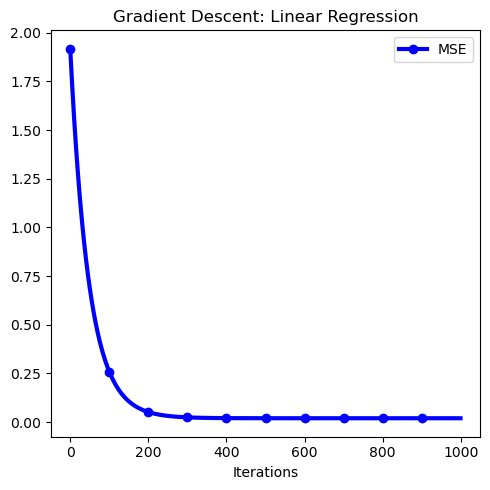

In [10]:
theta0 = rng.random(d)
est_theta, loss_values = gradient_descent(
    theta0, X_reg, y_reg, linreg_loss, linreg_gradient, step_size=1e-2, n_iter=1000
)

fig, ax = plt.subplots(1, 1, figsize=(5, 5), layout='tight')
ax.plot(loss_values, linewidth=3, color='b', marker='o', markevery=100, label='MSE')
ax.set_xlabel('Iterations')
ax.legend()
ax.set_title('Gradient Descent: Linear Regression')

rel_dist = np.linalg.norm(est_theta - true_theta) / np.linalg.norm(true_theta)
print(f"Relative distance from the true parameter: {rel_dist:.2%}")

**Visualizing the result.** With $d=10$ we cannot draw the loss surface, but two pictures tell
us the optimization worked. On the **left**, the loss on a log scale: a straight line means the
error shrinks by a constant factor each step (the fast, *linear* convergence of GD on this nice
convex problem). On the **right**, the model's predictions $\hat y = \theta^\top x$ against the true
targets: after training they line up on the diagonal. *(Provided, just run it.)*

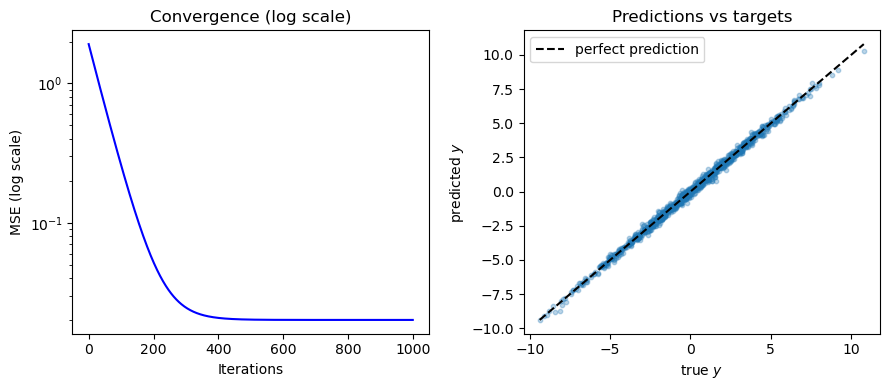

In [11]:
y_pred = X_reg @ est_theta

fig, axs = plt.subplots(1, 2, figsize=(9, 4), layout='tight')
axs[0].semilogy(loss_values, color='b')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('MSE (log scale)')
axs[0].set_title('Convergence (log scale)')

axs[1].scatter(y_reg, y_pred, s=10, alpha=0.3)
lims = [y_reg.min(), y_reg.max()]
axs[1].plot(lims, lims, 'k--', label='perfect prediction')
axs[1].set_xlabel('true $y$')
axs[1].set_ylabel('predicted $y$')
axs[1].set_title('Predictions vs targets')
axs[1].legend()
plt.show()

## Part 3: Logistic regression

We now switch to a binary classification problem. The dataset contains pairs $(x, y)$ where $x$
is a 2D point and $y \in \{-1, +1\}$ is the label. Positive samples are drawn from
$\mathcal{N}(\mu_+, \sigma^2 I)$ and negative samples from $\mathcal{N}(\mu_-, \sigma^2 I)$.

The model and the optimizer stay the same, only the loss $\ell$ changes.

In [12]:
n_cls = 300   # samples per class
d_cls = 2     # dimension

mu_pos = 1.0 * np.ones(d_cls)
mu_neg = -1.0 * np.ones(d_cls)
sigma = 1.0

X_pos = mu_pos + sigma * rng.standard_normal((n_cls, d_cls))
y_pos = np.ones(n_cls)
X_neg = mu_neg + sigma * rng.standard_normal((n_cls, d_cls))
y_neg = -np.ones(n_cls)

X_clf = np.vstack((X_pos, X_neg))
y_clf = np.hstack((y_pos, y_neg))

Let us visualize the generated points.

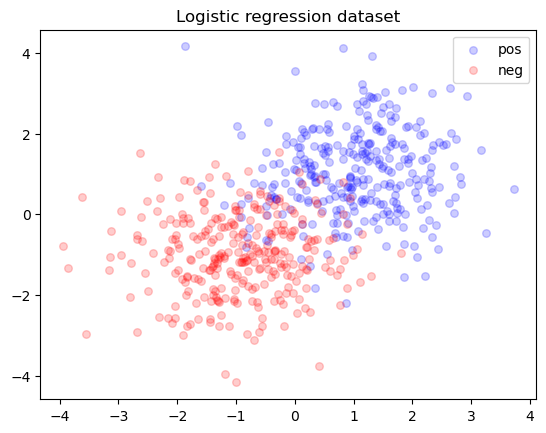

In [13]:
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=30, color='b', label='pos', alpha=.2)
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=30, color='r', label='neg', alpha=.2)
plt.legend()
plt.title('Logistic regression dataset')
plt.show()

### Question 3.1
We model the posterior probability with
$$
  \mathbb{P}(Y=+1 \mid X=x) = \frac{\exp(\theta^\top x)}{1 + \exp(\theta^\top x)} \enspace.
$$
Using the negative log-likelihood as the loss, write the expression of $\mathcal{L}(\theta)$.

*Hint:* with labels in $\{-1, +1\}$, the per-sample loss can be written compactly as
$\ell(\theta; x, y) = \log\!\big(1 + \exp(-y\, \theta^\top x)\big)$.

**Answer 3.1.** Write $\sigma(z) = \frac{1}{1 + e^{-z}}$ for the sigmoid, so that $\mathbb{P}(Y=+1 \mid X=x) = \sigma(\theta^\top x)$. The complementary probability is
$$
  \mathbb{P}(Y=-1 \mid X=x) = 1 - \sigma(\theta^\top x) = \frac{1}{1 + \exp(\theta^\top x)} = \sigma(-\theta^\top x) \enspace,
$$
so both cases combine into a single formula for $y \in \{-1, +1\}$:
$$
  \mathbb{P}(Y=y \mid X=x) = \sigma(y\, \theta^\top x) = \frac{1}{1 + \exp(-y\, \theta^\top x)} \enspace.
$$
The loss is the negative log-likelihood of the data, averaged over the $n$ samples:
$$
  \mathcal{L}(\theta)
  = -\frac{1}{n} \sum_{i=1}^n \log \mathbb{P}(Y=y_i \mid X=x_i)
  = \frac{1}{n} \sum_{i=1}^n \log\!\big(1 + \exp(-y_i\, \theta^\top x_i)\big) \enspace,
$$
which is exactly the average of the per-sample losses given in the hint.

### Question 3.2
Define `logreg_loss(theta, X, y)` computing the average negative log-likelihood
$\mathcal{L}(\theta)$ on the dataset `(X, y)`.

In [14]:
def logreg_loss(theta, X, y):
    margins = y * (X @ theta)
    # log(1 + exp(-m)) computed stably as logaddexp(0, -m)
    return np.mean(np.logaddexp(0.0, -margins))

### Question 3.3
Derive the gradient of $\mathcal{L}(\theta)$ and implement `logreg_gradient(theta, X, y)`
returning $\nabla \mathcal{L}(\theta)$.

**Answer 3.3 (derivation).** For one sample, with $u = -y\, \theta^\top x$ and using $\frac{d}{du}\log(1 + e^u) = \frac{e^u}{1 + e^u} = \sigma(u)$, the chain rule gives
$$
  \nabla_\theta \log\!\big(1 + \exp(-y\, \theta^\top x)\big)
  = \sigma(-y\, \theta^\top x) \cdot (-y\, x)
  = -\frac{y\, x}{1 + \exp(y\, \theta^\top x)} \enspace.
$$
Averaging over the dataset,
$$
  \nabla \mathcal{L}(\theta)
  = -\frac{1}{n} \sum_{i=1}^n \frac{y_i\, x_i}{1 + \exp(y_i\, \theta^\top x_i)}
  = -\frac{1}{n} X^\top \big(y \odot \sigma(-y \odot X\theta)\big) \enspace,
$$
where $\odot$ denotes the elementwise product. Note that $\sigma(-y_i\, \theta^\top x_i)$ is the probability the model assigns to the *wrong* label for sample $i$: confidently well-classified points contribute almost nothing to the gradient, while misclassified points contribute $\approx -y_i x_i$.

In [15]:
def logreg_gradient(theta, X, y):
    margins = y * (X @ theta)
    # sigmoid(-m) = exp(-logaddexp(0, m)), stable for large |m|
    sigmoid_neg_margins = np.exp(-np.logaddexp(0.0, margins))
    return -X.T @ (y * sigmoid_neg_margins) / X.shape[0]

### Question 3.4
Run the **same** `gradient_descent` from Part 2 on the logistic regression problem. The script
below also plots the resulting decision boundary.

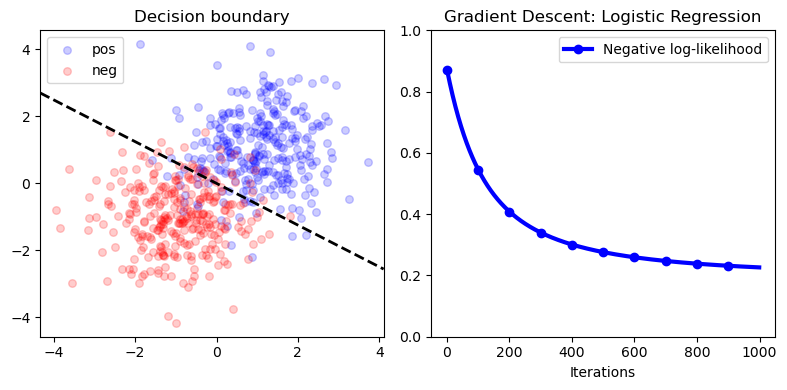

In [16]:
theta0 = np.array([-1., 1.])
est_theta, loss_values = gradient_descent(
    theta0, X_clf, y_clf, logreg_loss, logreg_gradient, step_size=1e-2, n_iter=1000
)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout='tight')

# Data points
axs[0].scatter(X_pos[:, 0], X_pos[:, 1], s=30, color='b', label='pos', alpha=.2)
axs[0].scatter(X_neg[:, 0], X_neg[:, 1], s=30, color='r', label='neg', alpha=.2)

# Decision boundary
axis_xlim = axs[0].get_xlim()
axis_ylim = axs[0].get_ylim()
axs[0].plot(axis_xlim, -np.array(axis_xlim) * est_theta[0] / est_theta[1],
            linewidth=2, linestyle='--', color='k')
axs[0].set_xlim(axis_xlim)
axs[0].set_ylim(axis_ylim)
axs[0].legend()
axs[0].set_title('Decision boundary')

# Loss
axs[1].plot(loss_values, linewidth=3, color='b', marker='o',
            markevery=100, label='Negative log-likelihood')
axs[1].set_ylim([0, 1.])
axs[1].set_xlabel('Iterations')
axs[1].legend()
axs[1].set_title('Gradient Descent: Logistic Regression')
plt.show()

**Watching the boundary move.** Gradient descent does not jump to the answer, it gets there
one step at a time. The cell below re-runs the descent and snapshots the decision boundary at four
iterations, from faint (start) to solid (converged), so you can see it rotate into place.
*(Provided, just run it.)*

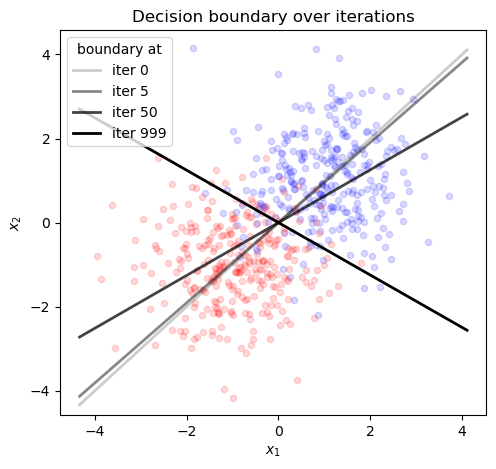

In [17]:
theta = np.array([-1., 1.])
snap_at = [0, 5, 50, 999]
snapshots = {}
for t in range(1000):
    if t in snap_at:
        snapshots[t] = theta.copy()
    theta = theta - 1e-2 * logreg_gradient(theta, X_clf, y_clf)

plt.figure(figsize=(5.5, 5))
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=20, color='b', alpha=.15)
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=20, color='r', alpha=.15)
xl = np.array(plt.xlim())
yl = plt.ylim()
ordered = sorted(snapshots.items())
shades = np.linspace(0.2, 1.0, len(ordered))  # faint to solid
for (t, th), shade in zip(ordered, shades):
    plt.plot(xl, -xl * th[0] / th[1], color='k', alpha=shade, linewidth=2,
             label=f'iter {t}')
plt.ylim(yl)
plt.legend(title='boundary at')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Decision boundary over iterations')
plt.show()

### Question 3.5
Try the procedure above for different values of `step_size`. What do you notice? Same question for
the data spread $\sigma$ (regenerate the dataset in the cell of Part 3 with a different `sigma`).

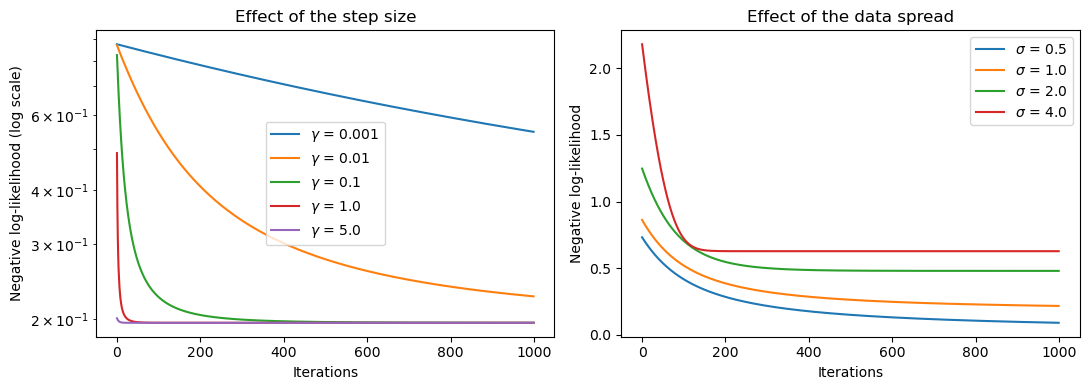

In [18]:
# Effect of the step size: same data, same init, different step sizes
step_sizes = [1e-3, 1e-2, 1e-1, 1.0, 5.0]
fig, axs = plt.subplots(1, 2, figsize=(11, 4), layout='tight')
for gamma in step_sizes:
    _, lv = gradient_descent(np.array([-1., 1.]), X_clf, y_clf,
                             logreg_loss, logreg_gradient,
                             step_size=gamma, n_iter=1000)
    axs[0].semilogy(lv, label=f'$\\gamma$ = {gamma}')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Negative log-likelihood (log scale)')
axs[0].set_title('Effect of the step size')
axs[0].legend()

# Effect of the data spread: datasets regenerated locally with different sigma,
# so the rest of the notebook keeps using the original X_clf, y_clf
sigmas = [0.5, 1.0, 2.0, 4.0]
for sigma_val in sigmas:
    r = np.random.default_rng(0)
    X_sig = np.vstack((mu_pos + sigma_val * r.standard_normal((n_cls, d_cls)),
                       mu_neg + sigma_val * r.standard_normal((n_cls, d_cls))))
    y_sig = np.hstack((np.ones(n_cls), -np.ones(n_cls)))
    _, lv = gradient_descent(np.array([-1., 1.]), X_sig, y_sig,
                             logreg_loss, logreg_gradient,
                             step_size=1e-2, n_iter=1000)
    axs[1].plot(lv, label=f'$\\sigma$ = {sigma_val}')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Negative log-likelihood')
axs[1].set_title('Effect of the data spread')
axs[1].legend()
plt.show()

**Answer 3.5 (observations).**

- **Step size $\gamma$:** with a very small step ($10^{-3}$) the loss decreases slowly and hasn't converged after 1000 iterations. Increasing $\gamma$ speeds up convergence, with $\gamma \approx 0.1$–$1$ converging fastest here. With a too-large step ($\gamma = 5$) the iterates overshoot: the loss oscillates and settles above the optimum instead of decreasing steadily. Unlike the quadratic of Part 0, the logistic loss has a bounded gradient, so the iterates bounce around rather than diverging to infinity — but they still fail to converge.

- **Data spread $\sigma$:** for small $\sigma$ the two classes are separated and the loss can be driven close to $0$ (i also think that if we had perfectly separable data the unregularized optimum would be at $\|\theta\| \to \infty$, so the loss keeps slowly decreasing as $\theta$ grows). For large $\sigma$ the classes overlap heavily and the loss plateaus at a much higher value: no linear boundary can separate the overlapping points, so that residual loss is irreducible — it reflects the data, not a failure of the optimizer. The direction of the decision boundary still seems to be found in the same number of iterations.

## Part 4: Stochastic and mini-batch gradient descent

Recall that the loss is an average over samples,
$$
  \mathcal{L}(\theta) = \frac{1}{n} \sum_{i=1}^n \ell(\theta; x_i, y_i) \enspace.
$$
Computing the full gradient requires summing $n$ partial gradients $\nabla \ell(\theta; x_i, y_i)$.
When $n$ is large, this becomes the bottleneck of the optimization.

**Stochastic Gradient Descent (SGD)** trades accuracy for speed: at each iteration it draws a
single sample $(x_i, y_i)$ uniformly at random and updates $\theta$ using
$\nabla \ell(\theta; x_i, y_i)$ as if it were the full gradient.

Note that our `grad_fn(theta, X, y)` already computes the gradient over *whatever* dataset it is
given, so we can obtain a stochastic gradient simply by passing it a single sample (or a few).

### Question 4.1
Complete the SGD implementation below. Use `grad_fn` on the randomly selected sample, keeping the
two-dimensional array shapes (e.g. `X[[idx]]`, `y[[idx]]`) so the same `grad_fn` works unchanged.

In [19]:
def stochastic_gradient_descent(theta0, X, y, loss_fn, grad_fn, step_size=1e-2, n_iter=1000):
    theta = theta0.copy()
    loss_evolution = []
    for _ in range(n_iter):
        idx = rng.integers(X.shape[0])  # pick one sample at random
        theta = theta - step_size * grad_fn(theta, X[[idx]], y[[idx]])
        loss_evolution.append(loss_fn(theta, X, y))
    return theta, loss_evolution

### Question 4.2
SGD can be improved by using a **mini-batch** of `batch_size` samples instead of a single one.
Modify the implementation so that it draws several indices at each iteration.

In [20]:
def minibatch_gradient_descent(theta0, X, y, loss_fn, grad_fn,
                               step_size=1e-2, n_iter=1000, batch_size=32):
    theta = theta0.copy()
    loss_evolution = []
    for _ in range(n_iter):
        idx = rng.integers(X.shape[0], size=batch_size)  # draw a mini-batch
        theta = theta - step_size * grad_fn(theta, X[idx], y[idx])
        loss_evolution.append(loss_fn(theta, X, y))
    return theta, loss_evolution

### Question 4.3
Compare full-batch gradient descent, SGD, and mini-batch SGD on the logistic regression problem.
Plot the three loss curves on the same figure. What do you observe in terms of convergence speed
and noise? (You can reuse `gradient_descent`, `stochastic_gradient_descent`, and
`minibatch_gradient_descent`, all with `logreg_loss` / `logreg_gradient`.)

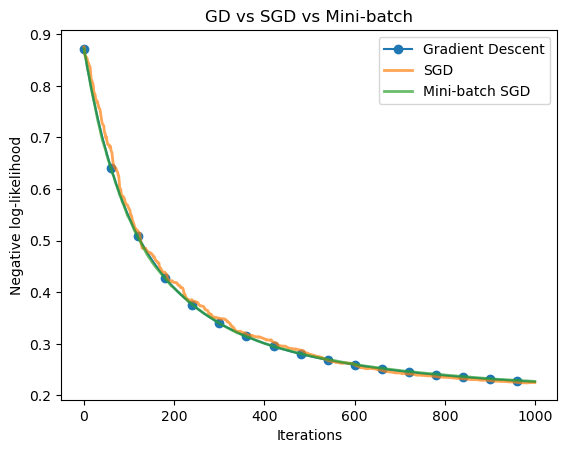

In [21]:
theta0 = np.array([-1., 1.])

_, loss_gd = gradient_descent(
    theta0, X_clf, y_clf, logreg_loss, logreg_gradient, step_size=1e-2, n_iter=1000)
_, loss_sgd = stochastic_gradient_descent(
    theta0, X_clf, y_clf, logreg_loss, logreg_gradient, step_size=1e-2, n_iter=1000)
_, loss_mb = minibatch_gradient_descent(
    theta0, X_clf, y_clf, logreg_loss, logreg_gradient, step_size=1e-2, n_iter=1000, batch_size=32)

plt.plot(loss_gd, label='Gradient Descent', marker='o', markevery=60)
plt.plot(loss_sgd, label='SGD', alpha=.7, linewidth=2)
plt.plot(loss_mb, label='Mini-batch SGD', alpha=.7, linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Negative log-likelihood')
plt.legend()
plt.title('GD vs SGD vs Mini-batch')
plt.show()

**Answer 4.3 (observations).**

- **Full-batch GD** decreases the loss smoothly and monotonically: each step uses the exact gradient, so the curve is clean — but every iteration costs a full pass over all $n = 600$ samples.
- **SGD** is very noisy: each step uses a single sample, so the gradient estimate has high variance. The loss drops quickly at first, then stops improving and fluctuates in a "noise ball" around the optimum — with a constant step size, the single-sample noise never averages out.
- **Mini-batch SGD** sits in between: averaging over 32 samples divides the gradient variance by the batch size, so its curve is much smoother than SGD's and tracks full GD closely, while each iteration remains far cheaper than a full pass.

Measured per *iteration*, full GD converges fastest. The fair comparison, however, is per *data access*: one GD step costs as much as 600 SGD steps or ~19 mini-batch steps, so per sample touched the stochastic methods make much faster progress — they are just noisier once they get close to the optimum. This trade-off is exactly why mini-batch SGD is the default optimizer in large-scale machine learning.

**Seeing the noise.** Because $\theta \in \mathbb{R}^2$ here, we can draw the **actual
trajectories** of the three methods on the contour lines of the logistic loss. Full-batch GD takes a
smooth path; SGD zig-zags because each step uses a single, high-variance gradient; mini-batch sits
in between. This is *the* picture of why SGD is fast but noisy. *(Provided, just run it.)*

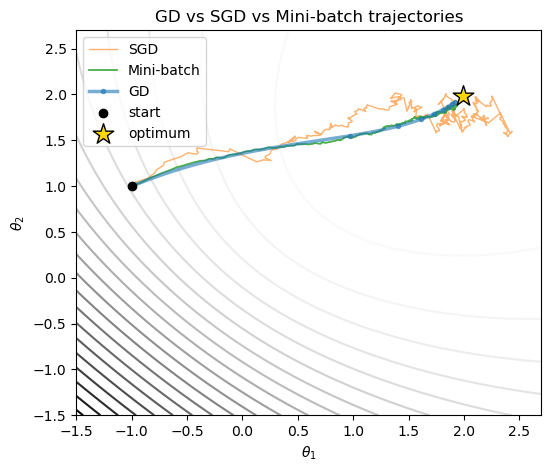

In [22]:
def descent_path(method, theta0, n_iter=800, step_size=0.1, batch_size=32):
    """Re-run a descent method, recording the full parameter trajectory."""
    theta = theta0.copy()
    path = [theta.copy()]
    for _ in range(n_iter):
        if method == 'gd':
            g = logreg_gradient(theta, X_clf, y_clf)
        elif method == 'sgd':
            i = rng.integers(X_clf.shape[0])
            g = logreg_gradient(theta, X_clf[[i]], y_clf[[i]])
        else:  # mini-batch
            idx = rng.integers(X_clf.shape[0], size=batch_size)
            g = logreg_gradient(theta, X_clf[idx], y_clf[idx])
        theta = theta - step_size * g
        path.append(theta.copy())
    return np.array(path)

theta0 = np.array([-1., 1.])
paths = {
    'GD': descent_path('gd', theta0),
    'SGD': descent_path('sgd', theta0),
    'Mini-batch': descent_path('mb', theta0),
}
theta_star = descent_path('gd', theta0, n_iter=3000, step_size=0.2)[-1]  # well-converged optimum

# Loss surface over a grid of theta values
g1 = np.linspace(-1.5, 2.7, 80)
g2 = np.linspace(-1.5, 2.7, 80)
G1, G2 = np.meshgrid(g1, g2)
Z = np.array([[logreg_loss(np.array([a, b]), X_clf, y_clf) for a, b in zip(row1, row2)]
              for row1, row2 in zip(G1, G2)])

plt.figure(figsize=(6, 5))
plt.contour(G1, G2, Z, levels=20, cmap='Greys')
styles = {
    'SGD': dict(color='C1', linewidth=1.0, alpha=0.6),
    'Mini-batch': dict(color='C2', linewidth=1.3, alpha=0.85),
    'GD': dict(color='C0', linewidth=2.5, marker='o', markevery=100, markersize=3, zorder=5, alpha=.6),
}
for name in ['SGD', 'Mini-batch', 'GD']:  # GD drawn last so it stays visible on top
    p = paths[name]
    plt.plot(p[:, 0], p[:, 1], label=name, **styles[name])
plt.scatter([theta0[0]], [theta0[1]], marker='o', color='k', zorder=6, label='start')
plt.scatter([theta_star[0]], [theta_star[1]], marker='*', s=240, color='gold',
            edgecolor='k', zorder=7, label='optimum')
plt.legend()
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('GD vs SGD vs Mini-batch trajectories')
plt.show()